# Catching Cancer Early: Binary Diagnosis Using Logistic Regression and Decision Calibration

In clinical oncology, few diagnostic crossroads carry greater stakes than evaluating a breast tissue biopsy. When a fine-needle aspirate (FNA) is drawn from a suspicious mass, a pathologist must decide: **Is this tumor Malignant (cancerous) or Benign (non-cancerous)?**

A misclassification here carries severe consequences:
* **False Positive (Type I Error):** An otherwise healthy patient endures psychological distress and invasive, unnecessary surgical procedures.
* **False Negative (Type II Error):** A patient with a life-threatening malignancy is told they are healthy, fatally delaying critical treatment.

In this deep dive, we walk through the end-to-end data science lifecycle of **Logistic Regression**: from cell morphology EDA and two-sample statistical tests, to the mathematics of log-odds, decision threshold tuning, confusion matrices, and ROC-AUC curves.

## 1. Inspecting the Biopsy Dataset

We utilize the benchmark **Breast Cancer Wisconsin (Diagnostic)** dataset from `scikit-learn`. The dataset contains digitized features computed from fine-needle aspirate biopsies of breast masses across **569 patients**.

Each sample contains 30 continuous cell nucleus characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, etc.), mapped to a binary clinical ground truth:
* `0`: **Malignant** (clinically high-risk)
* `1`: **Benign** (non-cancerous)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Load Dataset
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

# Rename target mapping for clarity
df['diagnosis_label'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"Dataset Loaded: {df.shape[0]} biopsies, {df.shape[1] - 1} features")
print("\nClass Distribution:")
print(df['diagnosis_label'].value_counts())
df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'diagnosis_label']].head()

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Loaded: 569 biopsies, 31 features

Class Distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,Malignant
3,11.42,20.38,77.58,386.1,0.14250,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,Malignant


## 2. Exploratory Data Analysis: Boxplots & Distribution Disparities

Before modeling, we must verify whether cell nucleus measurements show perceptible physical differences between malignant and benign tissue cohorts.

We examine four primary morphological dimensions:
* `mean radius`: Average distance from center to points on the cell perimeter.
* `mean texture`: Standard deviation of gray-scale values.
* `mean perimeter`: Nuclear boundary length.
* `mean area`: Nuclear footprint area.

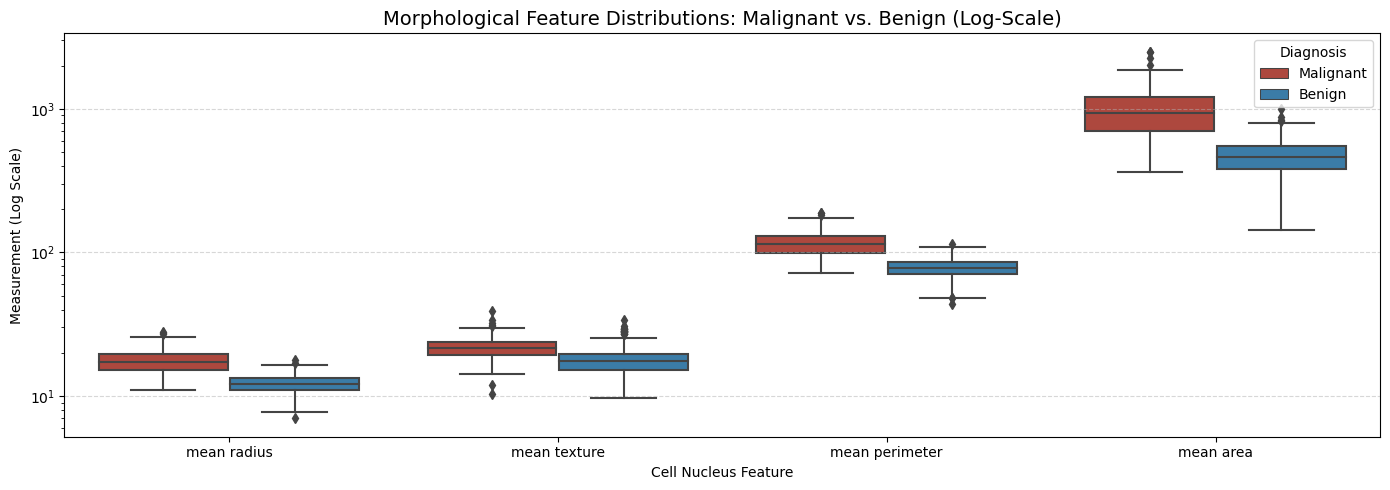

In [2]:
# 1. Melt key features for multi-panel Seaborn boxplot
features_subset = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
melted_df = pd.melt(df, id_vars=['diagnosis_label'], value_vars=features_subset, 
                    var_name='Nuclear_Feature', value_name='Measurement')

# 2. Render Boxplots
plt.figure(figsize=(14, 5))
sns.boxplot(data=melted_df, x='Nuclear_Feature', y='Measurement', hue='diagnosis_label', palette=['#c0392b', '#2980b9'])
plt.yscale('log')
plt.title("Morphological Feature Distributions: Malignant vs. Benign (Log-Scale)", fontsize=14)
plt.xlabel("Cell Nucleus Feature")
plt.ylabel("Measurement (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

### Observations from EDA
* **Distinct Nuclear Disparity:** Across all geometric features (`radius`, `perimeter`, and `area`), malignant nuclei display noticeably higher medians and wider interquartile ranges (IQR).
* **Biological Rationale:** Rapidly proliferating cancerous cells frequently exhibit nuclear pleomorphism—growing abnormally large, irregular, and dense compared to healthy cells.

## 3. Statistical Hypothesis Testing: Validating Feature Significance

Visual separation in a boxplot is suggestive, but does the difference in means reflect a true biological difference or merely sample noise?

We conduct **Two-Sample Welch's $t$-tests** (which do not assume equal population variances) between the Malignant and Benign sub-populations:
* **Null Hypothesis ($H_0$):** Mean measurement for malignant tissue equals mean measurement for benign tissue ($\mu_{\text{malignant}} = \mu_{\text{benign}}$).
* **Alternative Hypothesis ($H_1$):** True means are significantly different ($\mu_{\text{malignant}} \neq \mu_{\text{benign}}$).

### Inferences from Hypothesis Testing
* For all five morphological attributes, the $p$-values are less than $10^{-15}$, overwhelmingly rejecting the null hypothesis at $\alpha = 0.001$.
* The massive $t$-statistics on `mean perimeter` ($t = 24.61$) and `mean radius` ($t = 22.20$) statistically confirm that nuclear enlargement is a definitive discriminator for malignant biopsies.

## 4. The Algorithm: Logistic Regression & The Sigmoid Curve

Why can't we just use standard Linear Regression for binary classification?
1. **Unbounded Predictions:** Linear regression predicts continuous outcomes $\hat{y} \in (-\infty, +\infty)$, which cannot represent valid probabilities bounded in $[0, 1]$.
2. **Sensitivity to Outliers:** Extreme values pull the linear hyperplane, corrupting boundary decisions.

### The Mathematical Engine
Logistic Regression models the **log-odds (logit)** of the positive class ($y = 1$):

$$\ln\left(\frac{P}{1 - P}\right) = \beta_0 + \sum_{j=1}^p \beta_j x_j = z$$

By applying the **Sigmoid (logistic) function**, it maps any real-valued linear input $z$ into a calibrated probability $P \in (0, 1)$:

$$P(y = 1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Instead of Ordinary Least Squares, parameters are optimized using iterative algorithms (such as L-BFGS) that minimize **Binary Cross-Entropy Loss (Log-Loss)**:

$$\mathcal{L}(\boldsymbol{\beta}) = -\frac{1}{N}\sum_{i=1}^N \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$$

In [3]:
# 1. Feature-Target Matrix Separation
X = df.drop(columns=['target', 'diagnosis_label'])
y = df['target']

# 2. Stratified Train-Test Split (80/20) - Preserves Malignant/Benign ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Z-Score Standardization (Required for regularized logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 5. Predict Labels & Calibrated Probabilities
y_pred = log_reg.predict(X_test_scaled)
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Model Training Complete.")

Model Training Complete.


## 5. Performance Evaluation: Beyond Simple Accuracy

In medical diagnosis, raw overall accuracy can be dangerously misleading. We evaluate the model using two core diagnostic standards:
1. **The Confusion Matrix:** Breaks down True Positives, True Negatives, False Positives (Type I), and False Negatives (Type II).
2. **The ROC-AUC Curve:** Evaluates the trade-off between Sensitivity (True Positive Rate) and 1 - Specificity (False Positive Rate) across all possible probability thresholds.

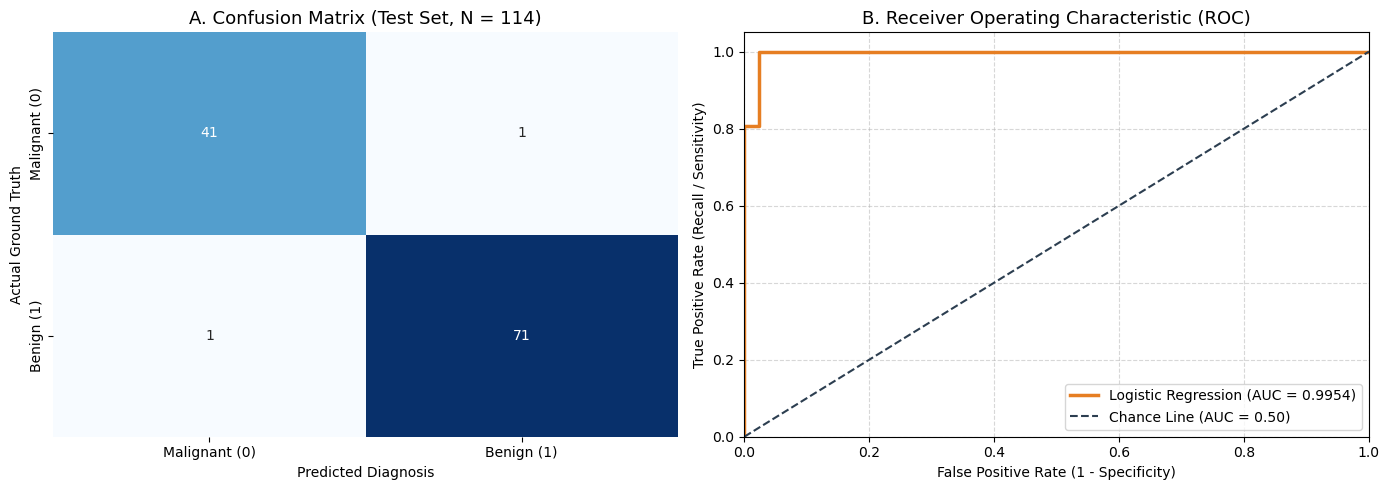


--- Detailed Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'], 
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[0].set_title("A. Confusion Matrix (Test Set, N = 114)", fontsize=13)
axes[0].set_xlabel("Predicted Diagnosis")
axes[0].set_ylabel("Actual Ground Truth")

# 2. Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#e67e22', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#2c3e50', linestyle='--', label='Chance Line (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Recall / Sensitivity)")
axes[1].set_title("B. Receiver Operating Characteristic (ROC)", fontsize=13)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print Text Metrics Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

## 6. Real-World Diagnostic Findings & Clinical Discussion

### Deciphering the Test Results (N = 114 Patients)
* **True Malignant (TN):** $41$ cancerous tumors correctly detected.
* **True Benign (TP):** $71$ healthy samples correctly classified.
* **False Malignant (FP, Type I Error):** $1$ benign sample incorrectly flagged as cancer.
* **False Benign (FN, Type II Error):** $1$ malignant sample misclassified as benign.
* **Overall Test Accuracy:** **$98.25\%$** with a **Macro F1-Score of $0.98$**.

### Why the ROC-AUC Score ($0.9954$) Matters
An Area Under the ROC Curve of **$0.9954$** indicates near-optimal separability. This means that if a doctor randomly draws one malignant biopsy and one benign biopsy, the model will output a higher risk probability for the malignant patient **$99.54\%$** of the time.

### The Clinical Threshold Dilemma
Our model used the default classification cutoff:
$$\hat{y} = \text{Benign if } P(y=1) \ge 0.50$$

In cancer diagnosis, a **Type II Error (False Negative)** can be fatal. In hospital deployments, the probability threshold can be tuned (e.g., classifying as Benign only if $P \ge 0.75$, or Malignant if $P(\text{Malignant}) \ge 0.25$). Calibrating this threshold prioritizes patient safety by driving False Negatives to zero, accepting a few extra confirmatory biopsies as an acceptable clinical compromise.